In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

import pymc as pm
from agent_based_model import load_data, preprocess_data
from main_pool import Main
from calibr_funcs import plot_results
from hybrid_abm_to_seir import ABC_Agent, generate_synthetic_data

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  #'5.24.0'

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


'5.24.0'

In [2]:
def switch_seir(sim_data, modeling_dur):
    switch_day = sim_data.shape[0]
    sigma = 1/2
    gamma = 1/6

    y0 = sim_data.tail(1).iloc[:,:4].values.flatten()
    # FOR FULL OBSERVED DATA
    ts = np.arange(modeling_dur-switch_day)


    #beta = before['beta_H1N1'].expanding(1).mean().values[-1]
    # Median from HM accepted parameters' trajectories!
    median_b = pd.read_csv('median_beta.csv')
    beta = median_b.iloc[switch_day:].values
    S,E,I,R = seir_discrete.seir_model(y0, ts, beta, 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    fin = np.array([*sim_data['I_H1N1'].values, *I])
    return fin

In [3]:
np.array([4])[0]

np.int64(4)

In [4]:
def simulation_func(rng, alpha, lmbd, modeling_duration, 
                    size=None):
    
    with_switch=True
    
    alpha = np.array(alpha).flatten()[0]
    lmbd = np.array(lmbd).flatten()[0]
    modeling_duration = np.array(modeling_duration).flatten()[0] 
    
    pool = Main(
        strains_keys=['H1N1', 'H3N2', 'B'],
        infected_init=[10, 0, 0],
        alpha=[alpha, alpha, alpha],
        lmbd=lmbd
    )
    num_runs = 2
    pool.runs_params(
        num_runs=num_runs,
        days=[1, modeling_duration],
        data_folder='check'
    )
    pool.age_groups_params(
        age_groups=['0-10', '11-17', '18-59', '60-150'],
        vaccined_fraction=[0, 0, 0, 0]
    )
    pool.start(with_seirb=True, with_switch=with_switch, frac=0.001)
    
    all_results = []
    for run_number in range(num_runs):
        results_path = os.path.join(pool.results_dir, 
                                    f"seirb_seed_{run_number}.csv")

        if os.path.exists(results_path):
            seirb_results = pd.read_csv(results_path, sep='\t')
            # обрезаем до нулей
            stop = seirb_results[seirb_results.I_H1N1==0].index
            if stop.shape[0]:
                seirb_results = seirb_results.iloc[:stop[0]]

            sim_data = switch_seir(seirb_results, modeling_duration)
            sim_results = pd.DataFrame(np.nan_to_num(sim_data),
                                      columns=['H1N1']).reset_index()
            all_results.append(sim_results)

    if all_results:
        combined_results = pd.concat(all_results, ignore_index=True)
        avg_results = combined_results.groupby('index'
                                              ).mean()['H1N1'].values
        return avg_results  

In [224]:
q = simulation_func(_, 1, 1, 250,
                    size=None)

In [5]:
data_p = 'check'
observed_data = pd.read_csv(f'results/{data_p}/observed.csv')
observed_data['I_H1N1'].values

array([1.00000e+01, 1.00000e+01, 1.60000e+01, 3.40000e+01, 5.10000e+01,
       8.40000e+01, 1.79000e+02, 3.63000e+02, 7.36000e+02, 1.44900e+03,
       3.05400e+03, 6.20200e+03, 8.62100e+03, 1.29560e+04, 2.00640e+04,
       3.36530e+04, 5.69190e+04, 8.55130e+04, 1.45480e+05, 1.56143e+05,
       1.91345e+05, 1.86623e+05, 2.35720e+05, 2.04175e+05, 1.68196e+05,
       1.53015e+05, 1.37502e+05, 1.30816e+05, 5.90030e+04, 6.70190e+04,
       4.10340e+04, 4.47990e+04, 1.94660e+04, 1.71330e+04, 1.66400e+04,
       8.41300e+03, 8.97200e+03, 5.44200e+03, 3.69800e+03, 3.45700e+03,
       1.87200e+03, 2.20900e+03, 1.13900e+03, 1.02300e+03, 9.53000e+02,
       6.48000e+02, 5.83000e+02, 2.39000e+02, 2.30000e+02, 1.13000e+02,
       8.60000e+01, 5.70000e+01, 2.80000e+01, 1.80000e+01, 1.10000e+01,
       8.00000e+00, 6.00000e+00, 2.00000e+00, 2.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.000

In [ ]:
'''
0.5 0.95
alpha 0.6 0.8375

0.2 0.9
lmbd 0.325 0.5

'''

In [6]:
tune = 1

draws = 10
chains = 1
progressbar = True

with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    alpha_v = pm.Uniform(name="alpha", lower=0., upper=1)
    lmbd_v = pm.Uniform(name="lmbd", lower=0., upper=1)
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = 249
    sim = pm.Simulator("sim", simulation_func, alpha_v, lmbd_v,
                        modeling_duration,
                        epsilon=1, 
                       ndims_params=[1,1,1],
                       observed=observed_data['I_H1N1'].values)
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))

Initializing SMC sampler...
Sampling 1 chain in 1 job


The number of samples is too small to check convergence reliably.
Sampling: [sim]


arviz - WARNING - Shape validation failed: input_shape: (1, 10), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.903,0.0,0.903,0.903,0.0,0.0,10.0,10.0,NaN
lmbd,0.523,0.0,0.523,0.523,0.0,0.0,7.0,10.0,NaN


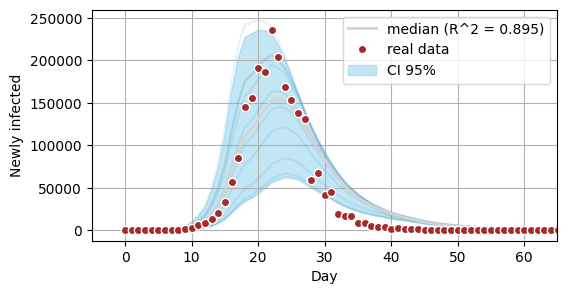

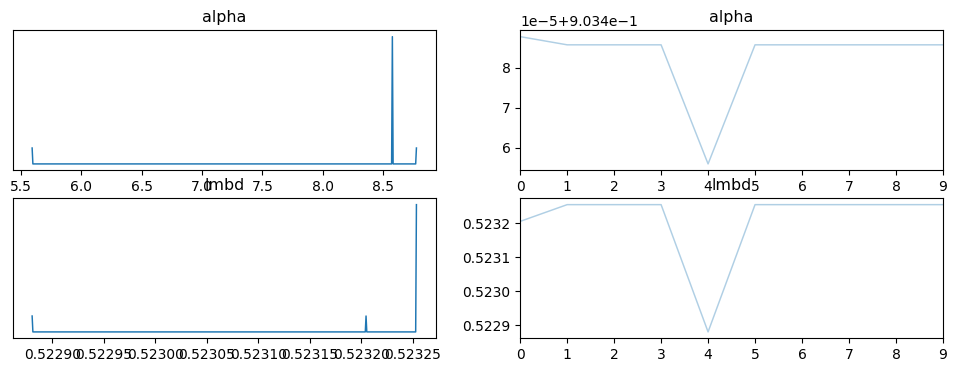

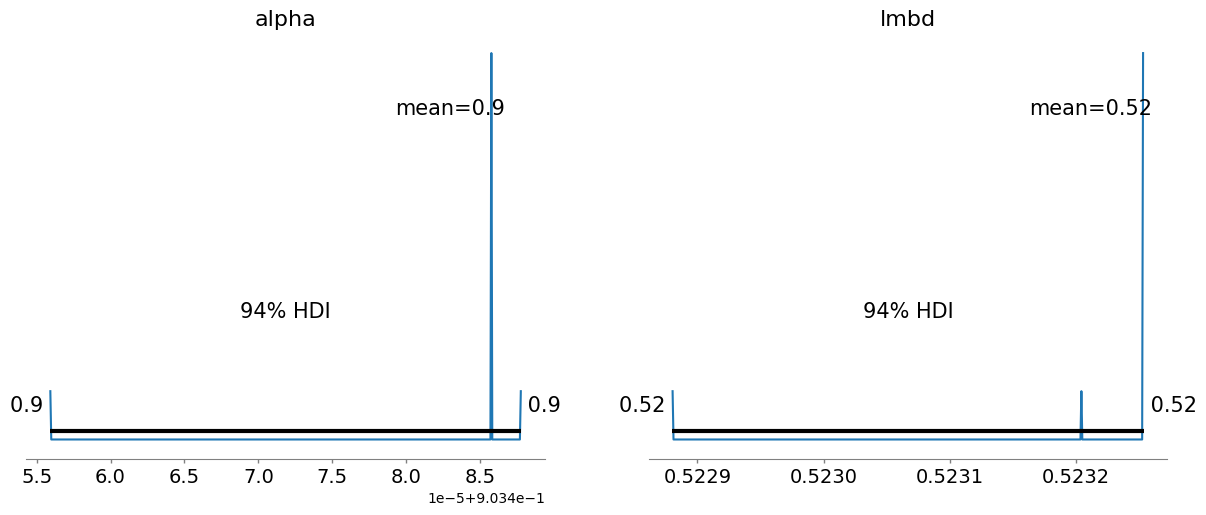

In [7]:
plot_funcs.plots(idata, observed_data['I_H1N1'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)
